<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/£P6/Data+Bottleneck/web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/£P6/Data+Bottleneck/erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/£P6/Data+Bottleneck/liaison.xlsx")

C:\Users\Arnaud\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\Arnaud\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\Arnaud\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

#display(df_erp.shape)
#df_erp.head()


Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
print(f"Le data frame 'df_erp' contient {df_erp.shape[1]} colonnes")

print("-------------------------------------------------------------------------")

#La nature des données dans chacune des colonnes
print("Les types de données pour chaque colonne sont les suivantes :")
print("")
display(df_erp.dtypes)

print("-------------------------------------------------------------------------")

#Le nombre de valeurs présentes dans chacune des colonnes
print(f"Dans chaque colonne, il y a {len(df_erp.index)} valeurs")
print("")
display(df_erp.count())

Le data frame 'df_erp' contient 6 colonnes
-------------------------------------------------------------------------
Les types de données pour chaque colonne sont les suivantes :



product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object

-------------------------------------------------------------------------
Dans chaque colonne, il y a 825 valeurs



product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64

In [7]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
doublon = df_erp.duplicated(subset = ["product_id"]).sum()
print(f"Il y a {doublon} doublon(s).")

Il y a 0 doublon(s).


In [9]:
#Afficher les valeurs distinctes de la colonne stock_status
print(df_erp["stock_status"].unique())

#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print("Ces valeurs sont liées aux colonnes 'product_id', 'onsale_web', 'stock_quantity', 'stock_status'")

['instock' 'outofstock']
Ces valeurs sont liées aux colonnes 'product_id', 'onsale_web', 'stock_quantity', 'stock_status'


In [10]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(lambda x: "outofstock" if x <= 0 else "instock")

In [11]:
##########vérifier
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [12]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [13]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
sum_stock_status = (df_erp["stock_status"] == df_erp["stock_status_2"]).sum()
print(sum_stock_status)

#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset

823


In [14]:
##Afficher le nombre de TRUE et FALSE
comparaison = (df_erp["stock_status"] == df_erp["stock_status_2"]).value_counts()
print(comparaison)

True     823
False      2
Name: count, dtype: int64


In [15]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [16]:
##Cette ligne crée une série de Vrai/Faux
filtre_ecart = df_erp["stock_status"] != df_erp["stock_status_2"]

##Application du filtre pour identifier les lignes en écart
ecarts = df_erp[filtre_ecart]

display(ecarts)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [17]:
#Corriger la ou les données incohérentes
#erp.loc[erp["stock_status"] != erp["stock_status_2"], "stock_status"] = erp["stock_status_2"]
##corriger seulement une des cellules
df_erp.at[4, "stock_status"] = "instock"
df_erp.at[398, "stock_status"] = "outofstock"

########## autre façon de faire
#df_erp.loc[df_erp["product_id"] == 4039, "stock_status"] = "instock"
#df_erp.loc[df_erp["product_id"] == 4885, "stock_status"] = "outofstock"

In [18]:
##vérifier modification (en sélectionnant les lignes [4, 398] et les colonnes des valeurs modifiées)
display(df_erp.loc[[4, 398], ['stock_status', 'stock_status_2']])

,stock_status,stock_status_2
4,instock,instock
398,outofstock,outofstock


In [19]:
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
##Cette ligne crée une série de Vrai/Faux
filtre_ecart = df_erp["stock_status"] != df_erp["stock_status_2"]

##Application du filtre pour identifier les lignes en écart
ecarts = df_erp[filtre_ecart]

display(ecarts)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [20]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp["price"].isnull().sum())) #Saisir l'instruction manquante dans la fonction format

#Afficher le prix minimum de la colonne "price"
print(f"Prix minimum : {df_erp["price"].min()}")

#Afficher le prix maximum de la colonne "price"
print(f"Prix maximum : {df_erp["price"].max()}")

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
prix_negatif_price = df_erp[df_erp["price"] < 0]
display(prix_negatif_price)



Nombres d'articles avec un prix non renseigné: 0
Prix minimum : -20.0
Prix maximum : 225.0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [21]:
######erreur de saisie, je mets tout à 0 et sans stock en attendant de vérifier ce qu'il en est

##modifier les lignes avec 'product_id' : 4233 & 5017
df_erp.loc[df_erp["product_id"] == 4233, "price"] = 0
df_erp.loc[df_erp["product_id"] == 5017, "price"] = 0

##modifier les lignes avec 'product_id' : 6594
df_erp.loc[df_erp["product_id"] == 6594, ["price", "stock_quantity", "stock_status", "stock_status_2"]] = [0, 0, "outofstock", "outofstock"]

######je vérifie
display(df_erp.iloc[[151, 469, 739]])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,0.0,0,outofstock,10.33,outofstock
469,5017,0,0.0,0,outofstock,4.34,outofstock
739,6594,0,0.0,0,outofstock,4.61,outofstock


In [22]:
df_erp["price"].describe()

count    825.000000
mean      32.232667
std       26.645280
min        0.000000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [23]:
df_erp["price"].isna().sum()

np.int64(0)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [24]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print(df_erp["stock_quantity"].min())

#Afficher la quantité maximum de la colonne "stock_quantity"
print(df_erp["stock_quantity"].max())

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
prix_negatif_stock_quantity = df_erp[df_erp["stock_quantity"] < 0]
display(prix_negatif_stock_quantity)

####### empêcher les ventes sur le site en attendant de vérifier les stocks réel
df_erp.at[573, "onsale_web"] = 0

-10
145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


In [25]:
######vérifier que les stocks inférieurs à 0 ne sont plus en vente sur le site
prix_negatif_stock_quantity = df_erp[df_erp["stock_quantity"] < 0]
display(prix_negatif_stock_quantity)

#################################   mettre  stock à 0

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,0,44.5,-1,outofstock,22.30,outofstock


In [26]:
#Corriger la ou les données incohérentes

##corriger les cellules : modifier les stocks

df_erp.loc[df_erp["product_id"] == 4973, ["stock_quantity", "stock_status", "stock_status_2"]] = [0, "outofstock", "outofstock"]
df_erp.loc[df_erp["product_id"] == 5700, ["stock_quantity", "stock_status", "stock_status_2"]] = [0, "outofstock", "outofstock"]

In [27]:
#Vérifier la modification en affichant les lignes 449 et 573
df_erp.loc[[449, 573]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,0,outofstock,4.96,outofstock
573,5700,0,44.5,0,outofstock,22.30,outofstock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [28]:
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,instock,23.77,instock


In [29]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
display(df_erp["onsale_web"].describe())
print("-------------------------------------------------")
display(df_erp["onsale_web"].isnull().sum())
print("-------------------------------------------------")
display(df_erp["onsale_web"].unique())
print("-------------------------------------------------")
print("La colonne 'onsale_web' indique si un produit est disponible en ligne ou non.")
print("1 signifie que le produit est en vente sur le site, 0 signifie que le produit n'est pas en vente sur le site")

count    825.000000
mean       0.866667
std        0.340141
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: onsale_web, dtype: float64

-------------------------------------------------


np.int64(0)

-------------------------------------------------


array([1, 0])

-------------------------------------------------
La colonne 'onsale_web' indique si un produit est disponible en ligne ou non.
1 signifie que le produit est en vente sur le site, 0 signifie que le produit n'est pas en vente sur le site


In [30]:
#Quelles sont les colonnes à conserver selon vous?
print("""Les colonnes a conserver sont les suivantes :
- product_id
- onsale_web
- price
- stock_quantity
- stock_status
- purchase_price
""")

Les colonnes a conserver sont les suivantes :
- product_id
- onsale_web
- price
- stock_quantity
- stock_status
- purchase_price



In [31]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
del df_erp["stock_status_2"]

In [32]:
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [33]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
print(f"Nombre de produits avec un prix d'achat < ou = à 0 : {(df_erp["purchase_price"] <= 0).sum()}")
print("-------------------------------------------------")

#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(f"Nombre de prix non renseigné : {df_erp["purchase_price"].isnull().sum()}")
print("-------------------------------------------------")

#Afficher le prix minimum de la colonne "purchase_price"
print(f"Prix min = {df_erp["purchase_price"].min()} €")
print("-------------------------------------------------")

#Afficher le prix maximum de la colonne "purchase_price"
print(f"Prix max = {df_erp["purchase_price"].max()} €")
print("-------------------------------------------------")


print(f"""Stats descriptives :

{df_erp["purchase_price"].describe()}""")

Nombre de produits avec un prix d'achat < ou = à 0 : 0
-------------------------------------------------
Nombre de prix non renseigné : 0
-------------------------------------------------
Prix min = 2.74 €
-------------------------------------------------
Prix max = 137.81 €
-------------------------------------------------
Stats descriptives :

count    825.000000
mean      16.940582
std       14.561840
min        2.740000
25%        7.590000
50%       12.710000
75%       22.020000
max      137.810000
Name: purchase_price, dtype: float64


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [34]:
#Dimension du dataset
df_web.info()
print("-----------------------------------------")

#Nombre d'observations
print(f"Nombre de lignes : {df_web.shape[0]}")

#Nombre de caractéristiques
print(f"Nombre de colonnes : {df_web.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [35]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
display(df_web.dtypes)
print("-----------------------------------------------")
#Le nombre de valeurs présentes dans chacune des colonnes
print(f"Dans chaque colonne, il y a {len(df_web.index)} observations")

sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent                     float64
guid                             object


-----------------------------------------------
Dans chaque colonne, il y a 1513 observations


In [36]:
df_web.head()

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,...,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,...,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,...,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [37]:
#Selon vous, quelles sont les colonnes à conserver ?

# sku
# total_sales
# tax_status
# post_date
# product_type
# post_title
# post_name
# post_modified_gmt
# post_type

In [38]:
#Selon vous, quelles sont les colonnes à conserver/supprimer ?
df_web_colonnes_retenues = [
    'sku',
    'total_sales',
    'tax_status',
    'post_date',
    'product_type',
    'post_title',
    'post_name',
    'post_modified_gmt',
    'post_type'
]

In [39]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération

df_web_analyses = df_web[df_web_colonnes_retenues]

In [40]:
##Affichage pour vérifier le résultat
df_web_analyses.head()

#Vérification du résultat
print(f"Nombre de lignes : {len(df_web)}")

Nombre de lignes : 1513


In [41]:
#Visualisation des valeurs de la colonne sku
print(df_web_analyses["sku"].unique())

#Quelles sont les valeurs qui ne semblent pas respecter la règle de codification?

######On cherche les SKU qui ne sont pas composés uniquement de chiffres sans repérer les valeurs nulles
anomalie = df_web_analyses[~df_web_analyses["sku"].astype(str).str.isdigit() & (df_web_analyses['sku'].notna())]
display(anomalie)
print("------------------------------------------------------")
print(f"Il y a {len(anomalie)} anomalie(s)")

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
272,13127-1,4.0,taxable,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 15:09:06,product
842,bon-cadeau-25-euros,7.0,NaN,2018-06-01 13:53:46,Autre,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 12:13:57,attachment
1117,13127-1,4.0,NaN,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 15:09:06,attachment
1387,bon-cadeau-25-euros,7.0,taxable,2018-06-01 13:53:46,NaN,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 12:13:57,product


------------------------------------------------------
Il y a 4 anomalie(s)


In [42]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
display(anomalie)
pd.unique(anomalie.sku)
anomalie.sku.value_counts()

,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
272,13127-1,4.0,taxable,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 15:09:06,product
842,bon-cadeau-25-euros,7.0,NaN,2018-06-01 13:53:46,Autre,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 12:13:57,attachment
1117,13127-1,4.0,NaN,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 15:09:06,attachment
1387,bon-cadeau-25-euros,7.0,taxable,2018-06-01 13:53:46,NaN,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 12:13:57,product


sku
13127-1                2
bon-cadeau-25-euros    2
Name: count, dtype: int64

In [43]:
#Identifier les lignes sans code article
print(f"Il y a {df_web_analyses["sku"].isna().sum()} lignes sans code article.")
print("")

ligne_sans_article = df_web_analyses[df_web_analyses["sku"].isna()]
display(ligne_sans_article)

Il y a 85 lignes sans code article.



,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
8,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
20,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
30,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
37,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
41,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1429,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1432,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1445,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN


In [44]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
#Supprimer les lignes
#Sugestion : ne permettre de mettre que des chiffres

In [45]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print(df_web_analyses[["sku"]].value_counts())
print("--------------------------------------------------")
print("On observe que des clés existent en doublons")

print(f"Nombre de lignes : {len(df_web_analyses)}")

doublons = df_web_analyses['sku'].duplicated().sum()
print(f'Le nombre de lignes en double : {doublons} valeurs')


#web_analyses.duplicated().value_counts()

sku                
38                     2
15779                  2
15741                  2
15745                  2
15746                  2
                      ..
14865                  2
14897                  2
14899                  2
14905                  2
bon-cadeau-25-euros    2
Name: count, Length: 714, dtype: int64
--------------------------------------------------
On observe que des clés existent en doublons
Nombre de lignes : 1513
Le nombre de lignes en double : 798 valeurs


In [46]:
#Les lignes sans code article semblent être toutes non renseignées

#Pour s'en assurer, réaliser les étapes suivantes:

#1 - Créer un dataframe avec uniquement les lignes sans code article
sans_sku = df_web_analyses[df_web_analyses["sku"].isna()]

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
sans_sku.info()
print("")
print("---------------------------------------------------------------------")
print("Tableau des lignes sans code article (code 'sku') :")
display(sans_sku)
print("---------------------------------------------------------------------")

##Affichage des lignes n'étant pas totalement vides
lignes_sans_sku_avec_donnees = sans_sku[sans_sku.notna().any(axis=1)]
print("Tableau des lignes sans code article (code 'sku') mais remplies :")
display(lignes_sans_sku_avec_donnees)
print("---------------------------------------------------------------------")
#3 - Que constatez-vous?

#Pour les codes articles identifiés, réalisez une analyse et définir l'action à entreprendre
print("""Je décide de supprimer les lignes sans code article.
\n Toutefois je fais remonter le problème concernant ces deux produits :
    - Pierre Jean Villa Condrieu Jardin Suspendu 2018 (-56 ventes)
    - Pierre Jean Villa Côte Rôtie Fongeant 2017 (-17 ventes)""")

print("---------------------------------------------------------------------")

print("Les lignes sans 'sku' ne comprennent presque que des lignes vides. Je choisis donc de les supprimer.")
print("---------------------------------------------------------------------")
df_web_analyses = df_web_analyses.dropna(subset=['sku'])
print(f"Nombre de lignes après suppression lignes avec 'sku' vides : {df_web_analyses.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   total_sales        2 non-null      float64       
 2   tax_status         2 non-null      object        
 3   post_date          2 non-null      datetime64[ns]
 4   product_type       2 non-null      object        
 5   post_title         2 non-null      object        
 6   post_name          2 non-null      object        
 7   post_modified_gmt  2 non-null      datetime64[ns]
 8   post_type          2 non-null      object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 6.6+ KB

---------------------------------------------------------------------
Tableau des lignes sans code article (code 'sku') :


,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
8,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
20,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
30,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
37,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
41,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1429,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1432,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1445,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN


---------------------------------------------------------------------
Tableau des lignes sans code article (code 'sku') mais remplies :


,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
1084,NaN,-56.0,taxable,2018-08-08 11:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 12:24:01,product
1087,NaN,-17.0,taxable,2018-07-31 12:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 12:24:15,product


---------------------------------------------------------------------
Je décide de supprimer les lignes sans code article.

 Toutefois je fais remonter le problème concernant ces deux produits :
    - Pierre Jean Villa Condrieu Jardin Suspendu 2018 (-56 ventes)
    - Pierre Jean Villa Côte Rôtie Fongeant 2017 (-17 ventes)
---------------------------------------------------------------------
Les lignes sans 'sku' ne comprennent presque que des lignes vides. Je choisis donc de les supprimer.
---------------------------------------------------------------------
Nombre de lignes après suppression lignes avec 'sku' vides : 1428


In [47]:
# Vérification de la bonne réalisation de l'action
df_web_analyses.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 0 to 1512
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                1428 non-null   object        
 1   total_sales        1428 non-null   float64       
 2   tax_status         714 non-null    object        
 3   post_date          1428 non-null   datetime64[ns]
 4   product_type       1427 non-null   object        
 5   post_title         1428 non-null   object        
 6   post_name          1428 non-null   object        
 7   post_modified_gmt  1428 non-null   datetime64[ns]
 8   post_type          1428 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 111.6+ KB


In [48]:
##Filtrer pour ne garder que les produits (et pas les pièces jointes/images)
df_web_analyses = df_web_analyses[df_web_analyses['post_type'] == 'product']
##Vérification du nouveau nombre de lignes
print(f"Nombre de ligne après suppresion doublons 'attachment' : {len(df_web_analyses)}")

print("---------------------------------------------------------------------")

print("Tableau après suppressions des lignes où 'post-type' est 'attachment' :")
display(df_web_analyses)

Nombre de ligne après suppresion doublons 'attachment' : 714
---------------------------------------------------------------------
Tableau après suppressions des lignes où 'post-type' est 'attachment' :


,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
2,14692,5.0,taxable,2019-03-19 10:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 19:40:31,product
4,15328,2.0,taxable,2019-03-27 18:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,agnes-levet-cote-rotie-maestria-2017,2020-07-25 13:45:02,product
6,16515,10.0,taxable,2018-06-02 09:31:31,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,chateau-turcaud-bordeaux-rouge-cuvee-majeure-2018,2020-08-27 08:11:12,product
11,16585,15.0,taxable,2018-02-16 14:03:16,Vin,Xavier Frissant Touraine Sauvignon 2019,xavier-frissant-touraine-sauvignon-2019,2020-08-27 07:30:36,product
14,12869,7.0,taxable,2019-03-28 14:29:35,Vin,Stéphane Tissot Arbois D.D. 2016,stephane-tissot-arbois-dd-2016,2019-12-13 14:40:01,product
...,...,...,...,...,...,...,...,...,...
1503,13074,4.0,taxable,2018-02-12 14:25:28,Vin,Château de Vaudieu Châteauneuf-du-Pape L'Avenu...,chateau-de-vaudieu-chateauneuf-du-pape-lavenue...,2019-12-09 09:40:03,product
1505,16322,0.0,taxable,2018-02-15 13:51:32,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-gassac-igp-pays-herault-guilhem-rouge-2019,2020-08-26 14:05:03,product
1507,12365,10.0,taxable,2019-01-29 15:53:05,Vin,Parés Baltà Penedès Electio 2013,pares-balta-penedes-electio-2013,2020-08-08 15:45:02,product
1508,16326,5.0,taxable,2019-04-18 11:32:46,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 07:24:46,product


In [49]:
#Vérification de l'absence de doublons
df_web_analyses['sku'].duplicated().sum()

np.int64(0)

In [50]:
#Affiche les lignes entières qui sont en doublons dans la colonne 'sku'
#df_web_analyses[df_web_analyses['sku'].duplicated()]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [51]:
#Dimension du dataset
#Nombre d'observations
print("---------------------------------------------------------------------")
print(f"Le dataset 'liaison' comporte {df_liaison.shape[0]} ligne(s)")
print("---------------------------------------------------------------------")

#Nombre de caractéristiques
print(f"Le dataset 'liaison' comporte {df_liaison.shape[1]} colonne(s)")

print("---------------------------------------------------------------------")

#df_liaison.info()
#print("---------------------------------------------------------------------")

display(df_liaison.describe(include='all'))

---------------------------------------------------------------------
Le dataset 'liaison' comporte 825 ligne(s)
---------------------------------------------------------------------
Le dataset 'liaison' comporte 2 colonne(s)
---------------------------------------------------------------------


,id_web,product_id
count,734.0,825.000000
unique,734.0,NaN
top,15298.0,NaN
freq,1.0,NaN
mean,NaN,5162.597576
std,NaN,902.644635
min,NaN,3847.000000
25%,NaN,4348.000000
50%,NaN,4907.000000
75%,NaN,5805.000000


In [52]:
#Consulter le nombre de colonnes liaison.
print(f"Nombre de colonnes : {df_liaison.shape[0]}")
print("---------------------------------------------------------------------")

#La nature des données dans chacune des colonnes
print(df_liaison.dtypes)

print("---------------------------------------------------------------------")

#Le nombre de valeurs présentes dans chacune des colonnes
print(f"La colonne 'id_web' comporte {df_liaison["id_web"].shape[0]} lignes.")
print("---------------------------------------------------------------------")
print(f"La colonne 'product_id' comporte {df_liaison["product_id"].shape[0]} lignes.")
print("---------------------------------------------------------------------")
print(f"""Nombres de lignes aves des valeurs nuls par colonne :
{df_liaison.notna().sum()}""")

Nombre de colonnes : 825
---------------------------------------------------------------------
id_web        object
product_id     int64
dtype: object
---------------------------------------------------------------------
La colonne 'id_web' comporte 825 lignes.
---------------------------------------------------------------------
La colonne 'product_id' comporte 825 lignes.
---------------------------------------------------------------------
Nombres de lignes aves des valeurs nuls par colonne :
id_web        734
product_id    825
dtype: int64


In [53]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
print(df_liaison["product_id"].is_unique)

True


In [54]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(df_liaison["id_web"].is_unique) # -> 'False' : toutes les valeurs ne sont pas uniques

doublons = df_liaison[df_liaison["id_web"].duplicated()]
doublons_sum = df_liaison['id_web'].duplicated().sum()
print(f'Il y a {doublons_sum} valeurs en double.')
#display(doublons)

False
Il y a 90 valeurs en double.


In [55]:
#Avons-nous des articles sans correspondance?
display(df_liaison.loc[df_liaison.id_web.isna()])

print(f"{df_liaison.loc[df_liaison.id_web.isna()].shape[0]} articles sans correspondance et qui ne sont donc pas commercialisés sur le site web")

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


91 articles sans correspondance et qui ne sont donc pas commercialisés sur le site web


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [56]:
#Fusion des fichiers df_erp et df_liaison

##Trouver colonnes communes aux 2 data frame pour la jointure
colonnes_communes = set(df_erp.columns) & set(df_liaison.columns)
print(list(colonnes_communes))

##Fusion avec 'indicator' pour connaître la provenance
df_merge = pd.merge(df_erp, df_liaison, on='product_id', how='outer', indicator=True)

['product_id']


In [57]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?  

##Vérification des correspondances
print(df_merge['_merge'].value_counts())
print("---------------------------------------------------------------------")

##On filtre les lignes qui ont matché mais dont l'id_web est vide
verif_nan = df_merge[(df_merge['_merge'] == 'both') & (df_merge['id_web'].isna())]
display(verif_nan)
print("---------------------------------------------------------------------")

nuls = df_merge.isna().sum()
display(nuls)
print("---------------------------------------------------------------------")
print(f"Il y a {nuls.sum()} lignes sans 'id_web'")

_merge
both          825
left_only       0
right_only      0
Name: count, dtype: int64
---------------------------------------------------------------------


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
19,4055,0,86.1,0,outofstock,37.88,NaN,both
49,4090,0,73.0,0,outofstock,33.79,NaN,both
50,4092,0,47.0,0,outofstock,25.25,NaN,both
119,4195,0,14.1,0,outofstock,7.36,NaN,both
131,4209,0,73.5,0,outofstock,33.01,NaN,both
...,...,...,...,...,...,...,...,...
817,7196,0,31.0,55,instock,31.20,NaN,both
818,7200,0,31.0,6,instock,15.54,NaN,both
819,7201,0,31.0,18,instock,16.02,NaN,both
820,7203,0,45.0,30,instock,23.48,NaN,both


---------------------------------------------------------------------


product_id         0
onsale_web         0
price              0
stock_quantity     0
stock_status       0
purchase_price     0
id_web            91
_merge             0
dtype: int64

---------------------------------------------------------------------
Il y a 91 lignes sans 'id_web'


In [58]:
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both


In [59]:
#df_merge.to_csv("df_merge.csv")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [60]:
df_web_analyses.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                714 non-null    object        
 1   total_sales        714 non-null    float64       
 2   tax_status         714 non-null    object        
 3   post_date          714 non-null    datetime64[ns]
 4   product_type       713 non-null    object        
 5   post_title         714 non-null    object        
 6   post_name          714 non-null    object        
 7   post_modified_gmt  714 non-null    datetime64[ns]
 8   post_type          714 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 55.8+ KB


In [61]:
df_web_analyses.shape[0]

714

In [62]:
#Fusionner les datasets df_merge et df_web_analyses
print('Je fais le choix de prendre l\'ensemble des données communes aux deux fichiers')

##Fusion avec 'indicator' pour connaître la provenance
df_merge = pd.merge(df_merge, df_web_analyses, left_on='id_web', right_on='sku', how='inner')

Je fais le choix de prendre l'ensemble des données communes aux deux fichiers


In [63]:
display(df_merge.head())
print(f"Nombre de lignes du nouveau dataframe : {df_merge.shape[0]}")

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
0,3847,1,24.2,16,instock,12.88,15298,both,15298,6.0,taxable,2018-02-08 12:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 08:30:29,product
1,3849,1,34.3,10,instock,17.54,15296,both,15296,9.0,taxable,2018-02-08 13:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 08:00:17,product
2,3850,1,20.8,0,outofstock,10.64,15300,both,15300,0.0,taxable,2018-02-08 14:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 16:15:03,product
3,4032,1,14.1,26,instock,6.92,19814,both,19814,12.0,taxable,2018-02-09 14:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,pierre-jean-villa-igp-gamine-2018,2020-01-04 15:36:01,product
4,4039,1,46.0,3,instock,23.77,19815,both,19815,3.0,taxable,2018-02-12 09:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 15:36:10,product


Nombre de lignes du nouveau dataframe : 714


In [64]:
#Avons-nous des lignes sans correspondance?
##### Vérification des éventuelles incohérences lors du merge
mask = df_merge['_merge'] != "both"
display(df_merge[mask])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type


In [65]:
# Vérification de l'absence de cellules vides
df_merge[df_merge['sku'].isna()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type


In [66]:
# Vérification du contenu du DF
df_merge.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         714 non-null    int64         
 1   onsale_web         714 non-null    int64         
 2   price              714 non-null    float64       
 3   stock_quantity     714 non-null    int64         
 4   stock_status       714 non-null    object        
 5   purchase_price     714 non-null    float64       
 6   id_web             714 non-null    object        
 7   _merge             714 non-null    category      
 8   sku                714 non-null    object        
 9   total_sales        714 non-null    float64       
 10  tax_status         714 non-null    object        
 11  post_date          714 non-null    datetime64[ns]
 12  product_type       713 non-null    object        
 13  post_title         714 non-null    object        
 14  post_name 

In [67]:
# Vérification complémentaire concernant les différents types de produits
df_merge['product_type'].unique()

array(['Vin', 'Champagne', 'Whisky', 'Cognac', nan, "Huile d'olive",
       'Gin'], dtype=object)

In [68]:
print(f'Le nombre de produits de type Champagne est de : {df_merge['product_type'].eq('Champagne').sum()}')
print(f'Le nombre de produits de type Vin est de : {df_merge['product_type'].eq('Vin').sum()}')
print(f'Le nombre de produits de type Whisky est de : {df_merge['product_type'].eq('Whisky').sum()}')
print(f'Le nombre de produits de type Cognac est de : {df_merge['product_type'].eq('Cognac').sum()}')
print(f'Le nombre de produits de type Gin est de : {df_merge['product_type'].eq('Gin').sum()}')
print(f'Le nombre de produits de type Huile d\'olive est de : {df_merge['product_type'].eq('Huile d\'olive').sum()}')
print(f'Le nombre de produits n\'ayant pas de type mentionné est de : {df_merge['product_type'].isna().sum()}')
df_merge[df_merge['product_type'].isna()]


Le nombre de produits de type Champagne est de : 28
Le nombre de produits de type Vin est de : 658
Le nombre de produits de type Whisky est de : 14
Le nombre de produits de type Cognac est de : 8
Le nombre de produits de type Gin est de : 2
Le nombre de produits de type Huile d'olive est de : 3
Le nombre de produits n'ayant pas de type mentionné est de : 1


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
410,4954,1,25.0,23,instock,13.3,bon-cadeau-25-euros,both,bon-cadeau-25-euros,7.0,taxable,2018-06-01 13:53:46,NaN,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 12:13:57,product


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

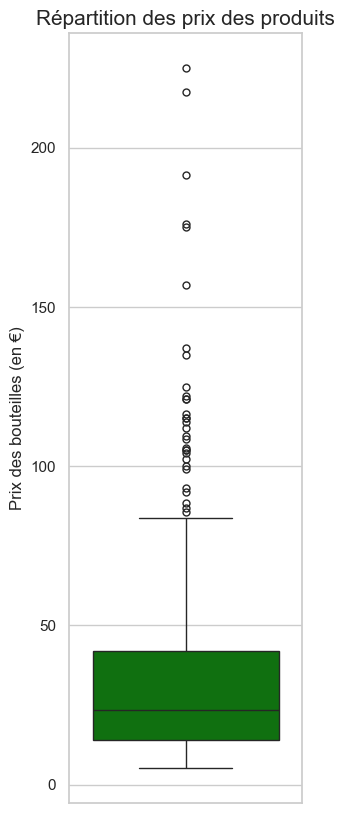

In [69]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set_theme(style="whitegrid")

# Création du boxplot
plt.figure(figsize=(3, 10))
sns.boxplot(y=df_merge["price"], color="green", fliersize=5)

# Ajout des titres et labels
plt.title("Répartition des prix des produits", fontsize=15)
plt.ylabel("Prix des bouteilles (en €)", fontsize=12)

plt.show()

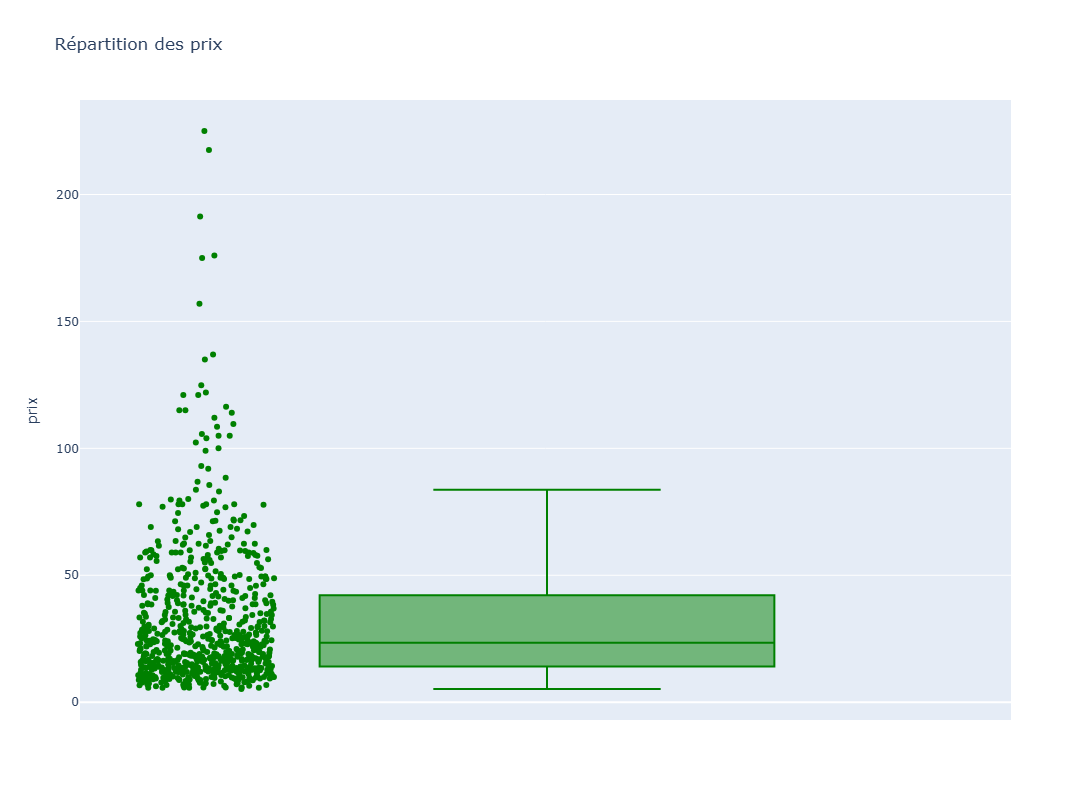

In [70]:
#Autre méthode avec plotly express
import plotly.express as px

# Création du boxplot interactif vertical
fig = px.box(df_merge, 
             y="price", 
             width=400,    # Largeur en pixels
             height=800,   # Hauteur en pixels
             color_discrete_sequence=["green"], # Liste de couleurs
             points="all", # Affiche tous les points (outliers et autres) à côté
             title="Répartition des prix",
             labels={"price": "prix"}) # Renomme 'price' en 'prix' sur l'axe

# Affichage du graphique
fig.show()

In [71]:
#Résumé statistique de la colonne 'price'
print(df_merge["price"].describe())

count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [72]:
#Calculer la moyenne du prix
import pandas as pd

moyenne_prix = df_merge["price"].mean()
print(f"Le prix moyen des vins est de : {moyenne_prix:.2f} €")
print("---------------------------------------------------------------------")
#Calculer l'écart-type du prix
import numpy as np

ecart_type = np.std(df_merge['price'])
print(f"Écart-type = {ecart_type:.2f}")
print("---------------------------------------------------------------------")
#Calculer le Z-score : 
z_score = round(moyenne_prix/ecart_type,2)
print(f"Z-score = {z_score}")
print("")
print(f"Note : Un Z-score inférieur à 2 est considéré comme un écart par rapport à la moyenne, tout à fait normal.")
print("---------------------------------------------------------------------")
# Ecart_type par rapport à la moyenne : coefficient de variation
coeff_variation = round(ecart_type/moyenne_prix,2)
print(f"Coefficient de variance = {coeff_variation}")


Le prix moyen des vins est de : 32.33 €
---------------------------------------------------------------------
Écart-type = 27.58
---------------------------------------------------------------------
Z-score = 1.17

Note : Un Z-score inférieur à 2 est considéré comme un écart par rapport à la moyenne, tout à fait normal.
---------------------------------------------------------------------
Coefficient de variance = 0.85


In [73]:
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
0,3847,1,24.2,16,instock,12.88,15298,both,15298,6.0,taxable,2018-02-08 12:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 08:30:29,product
1,3849,1,34.3,10,instock,17.54,15296,both,15296,9.0,taxable,2018-02-08 13:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 08:00:17,product
2,3850,1,20.8,0,outofstock,10.64,15300,both,15300,0.0,taxable,2018-02-08 14:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 16:15:03,product
3,4032,1,14.1,26,instock,6.92,19814,both,19814,12.0,taxable,2018-02-09 14:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,pierre-jean-villa-igp-gamine-2018,2020-01-04 15:36:01,product
4,4039,1,46.0,3,instock,23.77,19815,both,19815,3.0,taxable,2018-02-12 09:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 15:36:10,product


In [74]:
#Quel est le seuil prix dont le z-score est supérieur à 3?

##On crée une colonne pour indiquer le Z-score de chaque prix
df_merge['z_score'] = (df_merge['price'] - df_merge['price'].mean()) / df_merge['price'].std()
seuil_min = df_merge.loc[df_merge['z_score'] > 3, 'price'].min()

print(f'Le seuil de prix dont le Z-score est strictement supérieur à 3 est de : {seuil_min}')

Le seuil de prix dont le Z-score est strictement supérieur à 3 est de : 116.4


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [75]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge.price.describe()

count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64

In [76]:
#Définir un seuil pour les articles "outliers" en prix

q1_px = df_merge.price.quantile(0.25)
q3_px = df_merge.price.quantile(0.75)
iqr = q3_px - q1_px

px_limit_inf = q1_px - 1.5 * iqr
px_limit_sup = q3_px + 1.5 * iqr

print(f"Le premier quartile est de : {q1_px}\n"
      f"Le troisième quartile est de : {q3_px}\n"
      f"L'écart inter quantile est de : {round(iqr,2)}\n"
      f"L'outlier du premier quartile est de : {round(px_limit_inf,2)}\n"
      f"L'outlier du troisième quartile est de : {round(px_limit_sup,2)}\n")

Le premier quartile est de : 14.0625
Le troisième quartile est de : 42.075
L'écart inter quantile est de : 28.01
L'outlier du premier quartile est de : -27.96
L'outlier du troisième quartile est de : 84.09



In [77]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

df_merge['price_outlier_iqr'] = (df_merge.price > px_limit_sup) | (df_merge.price < px_limit_inf)
nb_prix_outlier = df_merge.price_outlier_iqr.sum()
prop_prix_outlier = round(nb_prix_outlier / df_merge.price.count() * 100, 2)

print(f"Nombre d'outliers : {nb_prix_outlier}")
print(f"Proportion d'outliers : {prop_prix_outlier} %")

Nombre d'outliers : 31
Proportion d'outliers : 4.34 %


In [78]:
df_outliers = df_merge[(df_merge['price']<px_limit_inf)|(df_merge['price']>px_limit_sup)]
df_outliers = df_outliers.sort_values('price', ascending=True)
#display(df_outliers.head(31))
display(df_outliers[['product_id', 'price','purchase_price', 'product_type','post_name', 'z_score']].sort_values(by='price', ascending=False).head(31))
print('On observe que les prix considérés comme "outliers" sont en réalité des produits de prestige tel que de Grands Crus, de Champagnes millésimés et de spiritueux haut de gamme')

,product_id,price,purchase_price,product_type,post_name,z_score
199,4352,225.0,137.81,Champagne,champagne-egly-ouriet-grand-cru-millesime-2008,6.981591
426,5001,217.5,116.87,Vin,david-duband-charmes-chambertin-grand-cru-2014,6.709816
587,5892,191.3,116.06,Champagne,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,5.760415
218,4402,176.0,78.25,Cognac,cognac-frapin-vip-xo,5.205993
553,5767,175.0,90.42,Vin,camille-giroud-clos-de-vougeot-2016,5.169756
221,4406,157.0,69.08,Cognac,cognac-frapin-chateau-de-fontpinot-1989-20-ans,4.517496
381,4904,137.0,67.95,Vin,domaine-des-croix-corton-charlemagne-grand-cru...,3.792762
642,6126,135.0,80.33,Champagne,champagne-gosset-celebris-vintage-2007,3.720288
511,5612,124.8,66.41,Vin,domaine-weinbach-gewurztraminer-gc-furstentum-...,3.350674
603,5917,122.0,54.24,Whisky,wemyss-malts-single-cask-scotch-whisky-choc-n-...,3.249211


On observe que les prix considérés comme "outliers" sont en réalité des produits de prestige tel que de Grands Crus, de Champagnes millésimés et de spiritueux haut de gamme


In [79]:
#Compte le nombre d'outliers contenant le mot 'cru' ou 'grand'
nb_grands_crus = df_outliers['post_name'].str.contains('cru|grand', case=False).sum()
print(f"Nombre de produits de type 'Grand Cru' parmi les outliers : {nb_grands_crus}")

Nombre de produits de type 'Grand Cru' parmi les outliers : 17


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [80]:
df_web.head()

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,...,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,...,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,...,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [81]:
#############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge['ca_par_article']=df_merge['price']*df_merge['total_sales']
display(df_merge)
#Calculer la somme de la colonne "ca_par_article"
ca_total=df_merge['ca_par_article'].sum()

#Ce résultat correspond au chiffre d'affaire du site web
print(f"Le chiffre d'affaire du site Web est de : {ca_total:,.2f} €".replace(",", " "))

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type,z_score,price_outlier_iqr,ca_par_article
0,3847,1,24.2,16,instock,12.88,15298,both,15298,6.0,taxable,2018-02-08 12:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 08:30:29,product,-0.294738,False,145.2
1,3849,1,34.3,10,instock,17.54,15296,both,15296,9.0,taxable,2018-02-08 13:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 08:00:17,product,0.071253,False,308.7
2,3850,1,20.8,0,outofstock,10.64,15300,both,15300,0.0,taxable,2018-02-08 14:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 16:15:03,product,-0.417943,False,0.0
3,4032,1,14.1,26,instock,6.92,19814,both,19814,12.0,taxable,2018-02-09 14:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,pierre-jean-villa-igp-gamine-2018,2020-01-04 15:36:01,product,-0.660729,False,169.2
4,4039,1,46.0,3,instock,23.77,19815,both,19815,3.0,taxable,2018-02-12 09:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 15:36:10,product,0.495222,False,138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,6930,1,8.4,28,instock,4.34,16135,both,16135,9.0,taxable,2020-04-25 13:22:38,Vin,Mouthes Le Bihan Côtes de Duras L'Aimé Chai 2015,mouthes-le-bihan-aime-chai-2015,2020-08-26 15:35:03,product,-0.867278,False,75.6
710,7023,1,27.5,23,instock,14.21,15891,both,15891,9.0,taxable,2020-05-02 14:53:40,Vin,Camin Larredya Jurançon Sec La Virada 2018,camin-larredya-jurancon-sec-la-virada-2018,2020-08-26 15:35:02,product,-0.175157,False,247.5
711,7025,1,69.0,8,instock,34.22,15887,both,15887,5.0,taxable,2020-05-02 15:00:54,Vin,Domaine Jamet Côte Rôtie Fructus Voluptas 2018,jamet-cote-rotie-fructus-voluptas-2018,2020-08-14 16:15:03,product,1.328666,False,345.0
712,7247,1,54.8,6,instock,27.18,13127-1,both,13127-1,4.0,taxable,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 15:09:06,product,0.814105,False,219.2


Le chiffre d'affaire du site Web est de : 143 680.10 €


In [82]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge = df_merge.sort_values('ca_par_article', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
display(df_merge['ca_par_article'].head(20))

#Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px

# On sélectionne les 20 premiers articles
top_20_articles = df_merge.head(20)

0     2475.0
1     1147.8
2     1113.0
3      824.0
4      805.0
5      781.2
6      735.0
7      700.0
8      675.0
9      672.0
10     633.6
11     628.0
12     627.0
13     616.0
14     599.2
15     594.0
16     582.0
17     556.5
18     537.6
19     528.0
Name: ca_par_article, dtype: float64

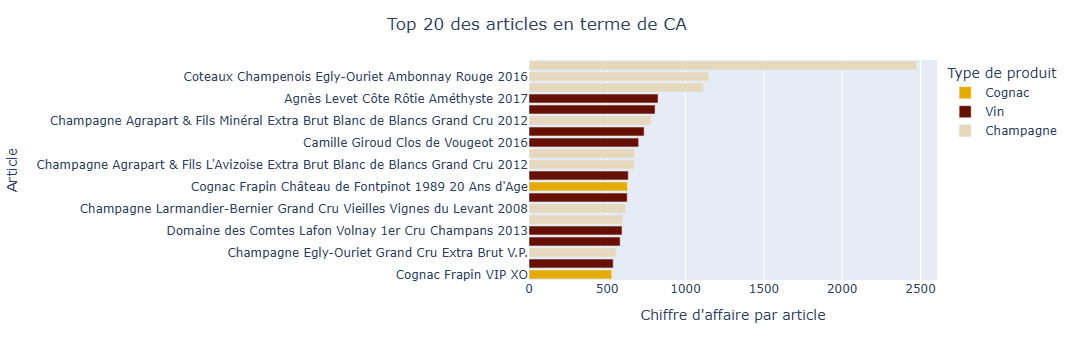

In [83]:
#Création du graphique en barres
df = df_merge.head(20).sort_values('ca_par_article', ascending=True)
palette = ["rgb(230,171,2)","rgb(102,17,0)", "rgb(229,216,189)"]

figure2 = px.bar(df, x='ca_par_article', y='post_title', color='product_type', 
                 labels={'post_title':"Article", 'ca_par_article':'Chiffre d\'affaire par article','product_type':'Type de produit'},
                 color_discrete_sequence=palette)
figure2.update_layout(title_text='Top 20 des articles en terme de CA',title_x=0.5)
figure2.update_yaxes(categoryorder='array', categoryarray=df['post_title'].tolist())
figure2.show()

In [84]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge['Part du CA']=round((df_merge['price']*df_merge['total_sales'])/ca_total*100,2)

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée : je vais donc classer par ordre décroissant (du plus contributif au moins contributif, au CA) 
    ### Puis je crée la colonne somme cumulée ligne 2 = cumul ligne 1 + 2 ; ligne 3 = cumul ligne 1 + 2 + 3 .... 
df_merge = df_merge.sort_values('Part du CA', ascending=False)

df_merge ['Somme cumulée'] = df_merge['Part du CA'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
art_80 = df_merge[df_merge['Somme cumulée'] <= 80]
nb_articles_80 = len(art_80)
print(f'Le nombre d\'articles représentant 80 % du CA est de : {nb_articles_80} articles')

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
prop_art=round(nb_articles_80/len(df_merge)*100,2)
print(f'La proportion que représente ce groupe d\'articles dans le catalogue entier du site web est de {prop_art} %')

Le nombre d'articles représentant 80 % du CA est de : 433 articles
La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de 60.64 %


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

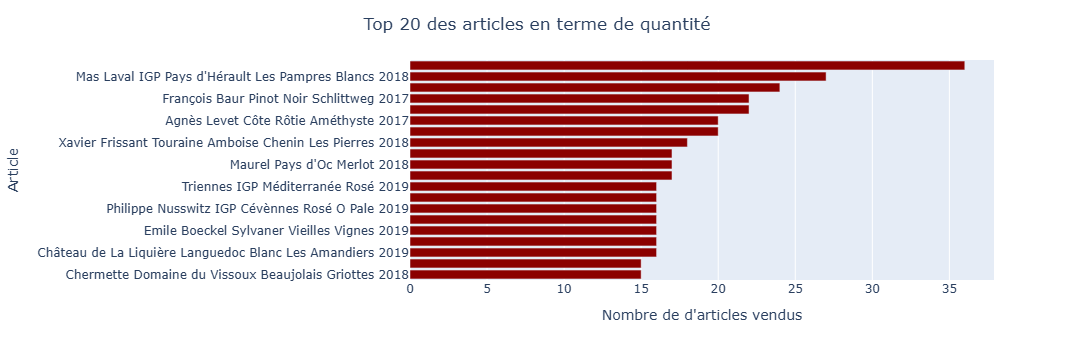

In [85]:
#####################################
# Palmarès des articles en quantité #
#####################################


#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge=df_merge.sort_values('total_sales', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge.reset_index

#Afficher les 20 premiers articles en quantité
df_merge.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
df_nb_art =df_merge.head(20).sort_values('total_sales', ascending=True)

figure3 = px.bar(df_nb_art, x='total_sales', y='post_title', labels={'post_title':"Article", 'total_sales':'Nombre de d\'articles vendus'}, color_discrete_sequence=['#8B0000'])
figure3.update_layout(title_text='Top 20 des articles en terme de quantité',title_x=0.5)
figure3.show()

In [86]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge['Part en quantité']=round((df_merge['total_sales']/df_merge['total_sales'].sum())*100,2)

# #Créer une colonne réalisant la somme cumulative de la colonne précedemment créée : je vais donc classer par ordre décroissant (du plus contributif au moins contributif, au CA) 
#     ### Puis je crée la colonne somme cumulée ligne 2 = cumul ligne 1 + 2 ; ligne 3 = cumul ligne 1 + 2 + 3 .... 
df_merge = df_merge.sort_values('Part en quantité', ascending=False)

df_merge ['Quantité cumulée'] = df_merge['Part en quantité'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
qtt_art_80 = df_merge[df_merge['Quantité cumulée'] <= 80]
nb_qtt_art_80 = len(qtt_art_80)
print(f'Le nombre d\'articles représentant 80% des ventes en quantité est de : {nb_qtt_art_80} articles')

# #Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
prop_qtt_art=round(nb_qtt_art_80/len(df_merge)*100,2)
print(f'La proportion que représente ce groupe d\'articles dans le catalogue entier du site web est de {prop_qtt_art} %')

Le nombre d'articles représentant 80% des ventes en quantité est de : 432 articles
La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de 60.5 %


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

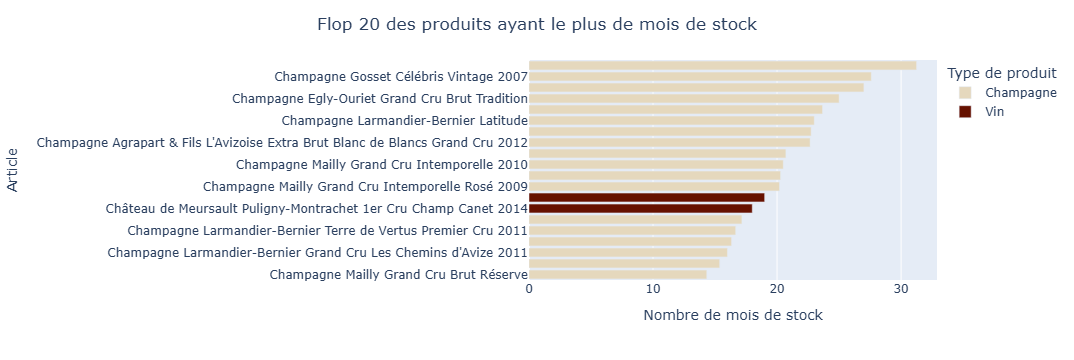

In [87]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
# -->> fait en initial

#Création de la colonne Rotation de stock
df_merge['rotation_stock']=df_merge['stock_quantity']/df_merge['total_sales']

#Remplacement des "inf" par 0
df_merge = df_merge.replace(np.inf, 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge=df_merge.sort_values('rotation_stock', ascending=False)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
df_stock =df_merge.head(20).sort_values('rotation_stock', ascending=True)

palette = ["rgb(229,216,189)","rgb(102,17,0)", "#D8D4A2"]

figure4 = px.bar(df_stock, x='rotation_stock', y='post_title', color='product_type', labels={'rotation_stock':'Nombre de mois de stock', 'post_title':"Article", 'product_type':'Type de produit'}, color_discrete_sequence=palette)
figure4.update_layout(title_text='Flop 20 des produits ayant le plus de mois de stock', title_x=0.5)

figure4.update_yaxes(categoryorder='array', categoryarray=df_stock['post_title'].tolist())

figure4.show()

In [88]:
####################################
# Valorisation des stocks en euros #
####################################

# (selon le prix de vente)
#Création de la colonne Valorisation des stocks en euros 
df_merge['Valorisation des stocks € (prix vente)'] = df_merge['stock_quantity'] * df_merge['purchase_price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
valeur_stock_vente = df_merge['Valorisation des stocks € (prix vente)'].sum()

print(f'La valeur du stock selon le prix de vente est de {valeur_stock_vente:,.2f} €'.replace(',',' '))

La valeur du stock selon le prix de vente est de 277 328.07 €


In [89]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
stock_total=df_merge['stock_quantity'].sum()
print(f'La quantité de bouteilles en stock est de {stock_total:,.0f} bouteilles'.replace(',',' '))

La quantité de bouteilles en stock est de 16 740 bouteilles


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [90]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge['prix_ht']=round((df_merge['price']/1.2),2)

#Création de la colonne Taux de marge
df_merge['taux_marge']=round((df_merge['prix_ht']-df_merge['purchase_price'])/df_merge['purchase_price']*100,2)

#Afficher le prix minimum de la colonne "taux_marge"
tx_marge_min=df_merge['taux_marge'].min()
print(f'Le taux de marge minimum est de : {tx_marge_min} %')

#Afficher le prix maximum de la colonne "taux_marge"
tx_marge_max=df_merge['taux_marge'].max()
print(f'Le taux de marge maximum est de : {tx_marge_max} %')

Le taux de marge minimum est de : -86.4 %
Le taux de marge maximum est de : 91.41 %


In [91]:
#Affichage de la ligne avec un taux de marge inférieur à 0
display(df_merge.loc[df_merge.taux_marge < 0])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,...,price_outlier_iqr,ca_par_article,Part du CA,Somme cumulée,Part en quantité,Quantité cumulée,rotation_stock,Valorisation des stocks € (prix vente),prix_ht,taux_marge
711,4355,1,12.65,97,instock,77.48,12589,both,12589,0.0,...,False,0.0,0.0,100.12,0.0,99.84,0.0,7515.56,10.54,-86.4


In [92]:
#Création d'un dataframe avec les taux positifs
df_merge_taux_positif = df_merge[df_merge['taux_marge'] > 0]

#Afficher le prix minimum de la colonne "taux_marge"
print(f'Minimum taux_marge : {df_merge['taux_marge'].min():.2f} %')

#Afficher le prix maximum de la colonne "taux_marge"
print(f'Le taux de marge maximum est de : {df_merge['taux_marge'].max():.2f} %')

Minimum taux_marge : -86.40 %
Le taux de marge maximum est de : 91.41 %


,product_type,taux_marge
3,Huile d'olive,33.41
0,Champagne,35.44
4,Vin,61.50
2,Gin,74.83
5,Whisky,81.74
1,Cognac,82.32


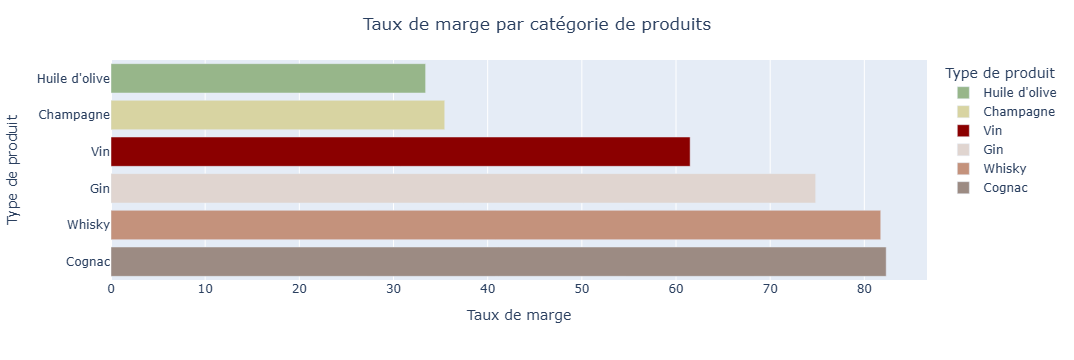

In [93]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_tx_marge_moyen = df_merge.groupby('product_type')['taux_marge'].mean().round(2).reset_index()
df_tx_marge_moyen = df_tx_marge_moyen.sort_values('taux_marge', ascending=True)
display(df_tx_marge_moyen)

#Affichage dans un graphique du taux de marge par type de produit
palette2 = ["#97B68A","#D8D4A2","#8B0000", "#E0D5D0","#C4927C","#9C8B83"]
figure5 = px.bar(df_tx_marge_moyen, x = 'taux_marge', y = 'product_type', color='product_type', labels={'taux_marge': 'Taux de marge', 'product_type':'Type de produit'}, color_discrete_sequence=palette2)
figure5.update_layout(title_text = 'Taux de marge par catégorie de produits',title_x=0.5)
figure5.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

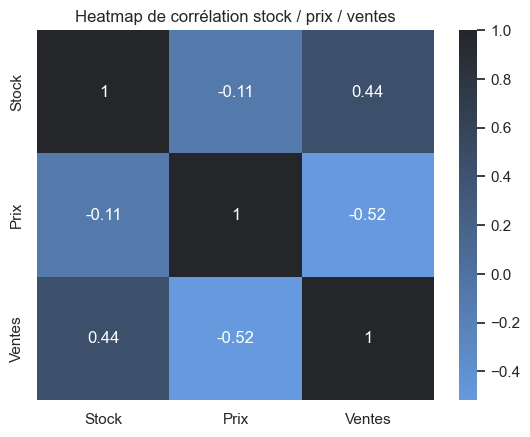

In [94]:
############################
# Analyse des corrélations #
############################

#Création d'une heatmap de corrélation avec les variables stock, sales et price
# plt.close('all')
corr = df_merge[['stock_quantity','price','total_sales']].corr()
labels = ['Stock', 'Prix', 'Ventes']
sns.heatmap(corr, annot=True, cmap = sns.dark_palette("#69d", reverse=True, as_cmap=True), xticklabels=labels,yticklabels=labels,)
plt.title('Heatmap de corrélation stock / prix / ventes')
plt.show()

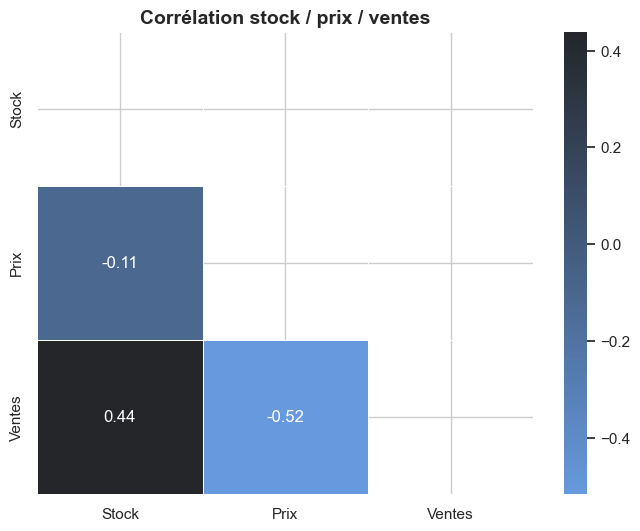

In [95]:
#On peut également créer un mask pour n'afficher qu'une demie heatmap
# Affichage de la moitié inférieure (avec mask de la moitié supérieure)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Affichage de la heatmap masquée
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap = sns.dark_palette("#69d", reverse=True, as_cmap=True), mask=mask, linewidths=0.5, xticklabels=labels, yticklabels=labels)
plt.title('Corrélation stock / prix / ventes', fontweight='bold', fontsize=14)
plt.show()

In [96]:
#Que peut-on conclure des corrélations ?
# stock et ventes : +0.44 // Corrélation positive modérée ➜ une stratégie de stockage cohérente avec les meilleures ventes du catalogue.
# prix et stock : -0.11 // Absence de lien significatif ➜ le prix n'est pas le levier principal de la stratégie de stockage.
# prix et ventes : -0.52 // Corrélation négative marquée ➜ l'augmentation du prix impacte significativement le volume de ventes.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [97]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_merge.to_csv('Fichier Bottleneck.xlsx', index=False)